# 🔬 Comparação de Modelos e Otimização

**Objetivo:** Melhorar as métricas do modelo de predição de risco de defasagem escolar.

## Índice
1. [Setup e Imports](#1-setup)
2. [Carregamento de Dados](#2-dados)
3. [Análise do Problema Atual](#3-problema)
4. [Pré-processamento Avançado](#4-preprocessing)
5. [Feature Engineering](#5-features)
6. [Comparação de Modelos](#6-modelos)
7. [Otimização com Optuna](#7-optuna)
8. [Técnicas de Balanceamento](#8-balanceamento)
9. [Análise Final e Recomendações](#9-conclusao)

---

| Versão | Data | Descrição |
|--------|------|-----------|
| v1.0 | Jan/2026 | Notebook inicial de comparação |

## 1. Setup e Imports <a id='1-setup'></a>

In [ ]:
# Instalar dependências necessárias (executar apenas uma vez)
# pip install xgboost lightgbm catboost optuna imbalanced-learn shap --quiet

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas básicas
import json
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate
)
from sklearn.preprocessing import (
    StandardScaler, 
    RobustScaler,
    QuantileTransformer,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    brier_score_loss
)

# Boosting libraries
try:
    import xgboost as xgb
    HAS_XGBOOST = True
    print("✅ XGBoost disponível")
except ImportError:
    HAS_XGBOOST = False
    print("⚠️ XGBoost não instalado")

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("✅ LightGBM disponível")
except ImportError:
    HAS_LIGHTGBM = False
    print("⚠️ LightGBM não instalado")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
    print("✅ CatBoost disponível")
except ImportError:
    HAS_CATBOOST = False
    print("⚠️ CatBoost não instalado")

# Optuna
try:
    import optuna
    from optuna.samplers import TPESampler
    HAS_OPTUNA = True
    print("✅ Optuna disponível")
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna não instalado")

# Imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
    print("✅ Imbalanced-learn disponível")
except ImportError:
    HAS_IMBLEARN = False
    print("⚠️ Imbalanced-learn não instalado")

# Configurações
SEED = 42
np.random.seed(SEED)

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"\n📁 Project root: {PROJECT_ROOT}")
print("✅ Setup concluído!")

✅ XGBoost disponível
✅ LightGBM disponível
✅ CatBoost disponível
✅ Optuna disponível
✅ Imbalanced-learn disponível

📁 Project root: c:\Users\argus\workspace\datathonfiap
✅ Setup concluído!


## 2. Carregamento de Dados <a id='2-dados'></a>

In [2]:
# Carregar dataset de modelagem
dataset_path = DATA_PATH / "modeling_dataset.parquet"

if dataset_path.exists():
    df = pd.read_parquet(dataset_path)
    print(f"✅ Dataset carregado: {df.shape}")
else:
    # Tentar CSV
    csv_path = DATA_PATH / "modeling_dataset.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"✅ Dataset carregado (CSV): {df.shape}")
    else:
        print(f"❌ Dataset não encontrado em {DATA_PATH}")
        print("Arquivos disponíveis:")
        for f in DATA_PATH.glob("*"):
            print(f"  - {f.name}")

✅ Dataset carregado: (765, 14)


In [3]:
# Visualizar dados
print("📊 Primeiras linhas:")
display(df.head())

print("\n📊 Info do dataset:")
print(df.info())

print("\n📊 Estatísticas descritivas:")
display(df.describe())

📊 Primeiras linhas:


,ra,instituicao_2023,idade_2023,genero_2023,fase_2023,ano_ingresso_2023,ian_2023,ida_2023,ieg_2023,iaa_2023,ips_2023,ipp_2023,ipv_2023,em_risco_2024
0,RA-861,Publica,8,Feminino,ALFA,2023,10.0,9.6,10.0,9.5,8.13,8.4375,8.920,1
1,RA-862,Publica,9,Masculino,ALFA,2023,5.0,8.9,9.1,8.5,8.14,7.5000,8.585,1
2,RA-863,Publica,7,Masculino,ALFA,2023,10.0,6.3,7.6,0.0,3.14,5.9375,6.260,1
3,RA-867,Publica,8,Masculino,ALFA,2023,10.0,8.9,8.6,9.0,8.76,7.5000,8.415,1
4,RA-868,Publica,7,Masculino,ALFA,2023,10.0,7.1,9.5,10.0,8.76,7.1875,8.670,1



📊 Info do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ra                 765 non-null    object 
 1   instituicao_2023   765 non-null    object 
 2   idade_2023         765 non-null    int64  
 3   genero_2023        765 non-null    object 
 4   fase_2023          765 non-null    object 
 5   ano_ingresso_2023  765 non-null    int64  
 6   ian_2023           765 non-null    float64
 7   ida_2023           693 non-null    float64
 8   ieg_2023           693 non-null    float64
 9   iaa_2023           706 non-null    float64
 10  ips_2023           703 non-null    float64
 11  ipp_2023           693 non-null    float64
 12  ipv_2023           693 non-null    float64
 13  em_risco_2024      765 non-null    int32  
dtypes: float64(7), int32(1), int64(2), object(4)
memory usage: 80.8+ KB
None

📊 Estatísticas descritivas:


,idade_2023,ano_ingresso_2023,ian_2023,ida_2023,ieg_2023,iaa_2023,ips_2023,ipp_2023,ipv_2023,em_risco_2024
count,765.000000,765.000000,765.000000,693.000000,693.000000,706.000000,703.000000,693.000000,693.000000,765.000000
mean,12.284967,2021.290196,7.405229,6.825685,8.864791,6.995184,5.156316,7.615455,8.116031,0.402614
std,3.368680,1.889478,2.519396,1.482296,0.970326,3.567116,2.091127,0.980503,0.919113,0.490745
min,7.000000,2016.000000,2.500000,2.200000,3.700000,0.000000,2.520000,4.375000,3.320000,0.000000
25%,10.000000,2021.000000,5.000000,5.900000,8.300000,6.925000,2.520000,7.187500,7.542500,0.000000
50%,12.000000,2022.000000,5.000000,6.900000,9.100000,8.500000,5.000000,7.708333,8.116667,0.000000
75%,14.000000,2023.000000,10.000000,7.900000,9.600000,9.200000,7.520000,8.281250,8.712500,1.000000
max,26.000000,2023.000000,10.000000,10.000000,10.000000,10.000000,9.380000,9.791667,10.010000,1.000000


🎯 Target: em_risco_2024
🔑 IDs: ['ra']
📊 Features (12): ['instituicao_2023', 'idade_2023', 'genero_2023', 'fase_2023', 'ano_ingresso_2023', 'ian_2023', 'ida_2023', 'ieg_2023', 'iaa_2023', 'ips_2023']...

📊 Distribuição do Target:
em_risco_2024
0    0.597386
1    0.402614
Name: proportion, dtype: float64


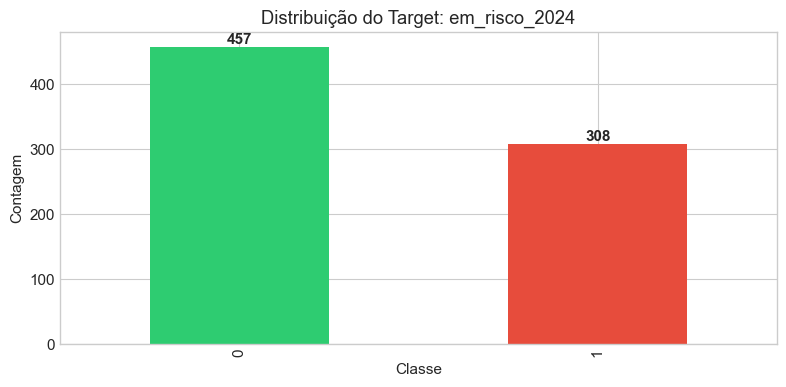

In [4]:
# Identificar target e features
TARGET_COL = [c for c in df.columns if c.startswith('em_risco')][0]
ID_COLS = ['ra'] if 'ra' in df.columns else []
FEATURE_COLS = [c for c in df.columns if c not in [TARGET_COL] + ID_COLS]

print(f"🎯 Target: {TARGET_COL}")
print(f"🔑 IDs: {ID_COLS}")
print(f"📊 Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:10]}...")

# Distribuição do target
print(f"\n📊 Distribuição do Target:")
target_dist = df[TARGET_COL].value_counts(normalize=True)
print(target_dist)

fig, ax = plt.subplots(figsize=(8, 4))
df[TARGET_COL].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title(f'Distribuição do Target: {TARGET_COL}')
ax.set_xlabel('Classe')
ax.set_ylabel('Contagem')
for i, v in enumerate(df[TARGET_COL].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Análise do Problema Atual <a id='3-problema'></a>

In [5]:
# Carregar métricas atuais
metrics_files = ['metrics.json', 'metrics_v1.json']
current_metrics = {}

for mf in metrics_files:
    path = ARTIFACTS_PATH / mf
    if path.exists():
        with open(path) as f:
            current_metrics[mf] = json.load(f)
        print(f"✅ Carregado: {mf}")

# Mostrar métricas atuais
if current_metrics:
    print("\n" + "="*60)
    print("📊 MÉTRICAS DO MODELO ATUAL")
    print("="*60)
    
    for name, metrics in current_metrics.items():
        print(f"\n📁 {name}:")
        print(f"   Best model: {metrics.get('best_model', 'N/A')}")
        print(f"   Threshold: {metrics.get('threshold', 'N/A'):.6f}")
        
        if 'validation_metrics' in metrics:
            vm = metrics['validation_metrics']
            print(f"   Recall: {vm.get('recall', 'N/A'):.4f}")
            print(f"   Precision: {vm.get('precision', 'N/A'):.4f}")
            print(f"   F1: {vm.get('f1', 'N/A'):.4f}")
            print(f"   PR-AUC: {vm.get('pr_auc', 'N/A'):.4f}")

✅ Carregado: metrics.json
✅ Carregado: metrics_v1.json

📊 MÉTRICAS DO MODELO ATUAL

📁 metrics.json:
   Best model: baseline1_logistic
   Threshold: 0.001186

📁 metrics_v1.json:
   Best model: hist_gb
   Threshold: 0.026820
   Recall: 1.0000
   Precision: 0.3984
   F1: 0.5698
   PR-AUC: 0.8587


In [6]:
# Análise do problema
print("🔍 DIAGNÓSTICO DO PROBLEMA ATUAL:")
print("="*60)
print("""
⚠️ PROBLEMAS IDENTIFICADOS:

1. THRESHOLD MUITO BAIXO (~0.026):
   - Indica baixa capacidade discriminativa
   - Modelo prediz quase tudo como positivo
   - Recall alto (100%) mas precision baixa (~40%)

2. TRADE-OFF DESFAVORÁVEL:
   - Para atingir recall alto, sacrifica precision
   - F1-score ~0.58 está abaixo do esperado

3. POSSÍVEIS CAUSAS:
   - Features não discriminativas o suficiente
   - Preprocessing perdendo informação
   - Modelo não otimizado
   - Dataset pequeno (~765 amostras)

🎯 METAS PARA MELHORIA:
   - PR-AUC > 0.90
   - F1 > 0.70
   - Precision > 50% mantendo Recall > 75%
   - Threshold mais equilibrado (0.3-0.5)
""")

🔍 DIAGNÓSTICO DO PROBLEMA ATUAL:

⚠️ PROBLEMAS IDENTIFICADOS:

1. THRESHOLD MUITO BAIXO (~0.026):
   - Indica baixa capacidade discriminativa
   - Modelo prediz quase tudo como positivo
   - Recall alto (100%) mas precision baixa (~40%)

2. TRADE-OFF DESFAVORÁVEL:
   - Para atingir recall alto, sacrifica precision
   - F1-score ~0.58 está abaixo do esperado

3. POSSÍVEIS CAUSAS:
   - Features não discriminativas o suficiente
   - Preprocessing perdendo informação
   - Modelo não otimizado
   - Dataset pequeno (~765 amostras)

🎯 METAS PARA MELHORIA:
   - PR-AUC > 0.90
   - F1 > 0.70
   - Precision > 50% mantendo Recall > 75%
   - Threshold mais equilibrado (0.3-0.5)



## 4. Pré-processamento Avançado <a id='4-preprocessing'></a>

In [7]:
# Preparar X e y
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f"📊 Shape X: {X.shape}")
print(f"📊 Shape y: {y.shape}")

# Verificar missing values
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print(f"\n⚠️ Features com missing values:")
    display(missing_df)
else:
    print("\n✅ Nenhum missing value encontrado")

📊 Shape X: (765, 12)
📊 Shape y: (765,)

⚠️ Features com missing values:


,Missing,Percent
ida_2023,72,9.41
ieg_2023,72,9.41
ipv_2023,72,9.41
ipp_2023,72,9.41
ips_2023,62,8.10
iaa_2023,59,7.71


In [8]:
# Identificar tipos de colunas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"📊 Colunas numéricas ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"📊 Colunas categóricas ({len(categorical_cols)}): {categorical_cols}")

📊 Colunas numéricas (9): ['idade_2023', 'ano_ingresso_2023', 'ian_2023', 'ida_2023', 'ieg_2023']...
📊 Colunas categóricas (3): ['instituicao_2023', 'genero_2023', 'fase_2023']


🔬 COMPARANDO ESTRATÉGIAS DE IMPUTAÇÃO
✅ median: Imputação concluída
✅ mean: Imputação concluída
✅ knn_3: Imputação concluída
✅ knn_5: Imputação concluída
✅ iterative: Imputação concluída


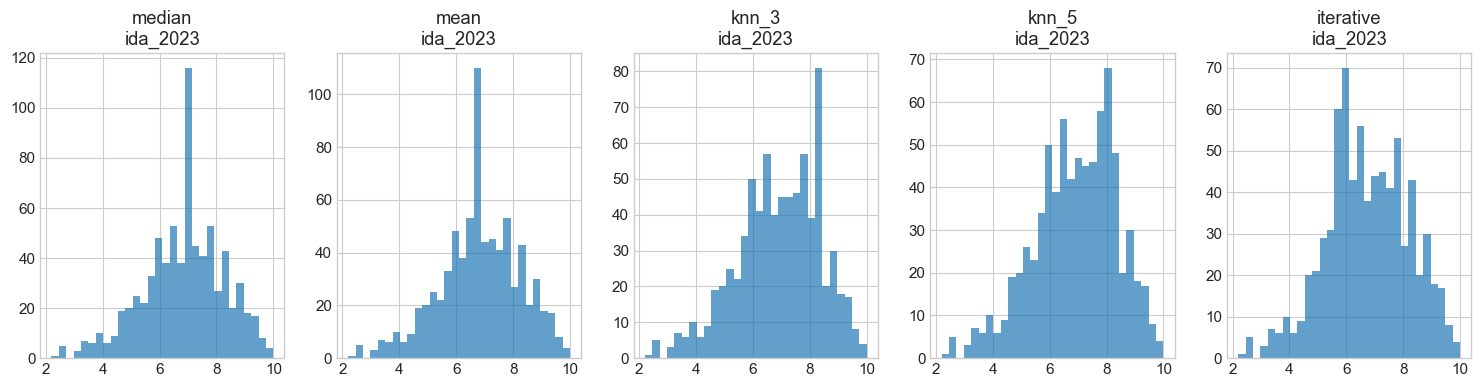

In [9]:
# Comparar diferentes estratégias de imputação
print("🔬 COMPARANDO ESTRATÉGIAS DE IMPUTAÇÃO")
print("="*60)

imputation_strategies = {
    'median': SimpleImputer(strategy='median'),
    'mean': SimpleImputer(strategy='mean'),
    'knn_3': KNNImputer(n_neighbors=3),
    'knn_5': KNNImputer(n_neighbors=5),
    'iterative': IterativeImputer(max_iter=10, random_state=SEED)
}

# Se houver missing values, comparar
if X.isnull().sum().sum() > 0:
    X_numeric = X[numeric_cols].copy()
    
    imputed_data = {}
    for name, imputer in imputation_strategies.items():
        try:
            imputed = imputer.fit_transform(X_numeric)
            imputed_data[name] = pd.DataFrame(imputed, columns=numeric_cols)
            print(f"✅ {name}: Imputação concluída")
        except Exception as e:
            print(f"❌ {name}: {e}")
    
    # Comparar distribuições
    if imputed_data:
        col_to_check = missing_df.index[0] if len(missing_df) > 0 else numeric_cols[0]
        
        fig, axes = plt.subplots(1, len(imputed_data), figsize=(15, 4))
        for ax, (name, data) in zip(axes, imputed_data.items()):
            data[col_to_check].hist(ax=ax, bins=30, alpha=0.7)
            ax.set_title(f'{name}\n{col_to_check}')
        plt.tight_layout()
        plt.show()
else:
    print("✅ Sem missing values - imputação não necessária")

🔬 COMPARANDO ESTRATÉGIAS DE SCALING


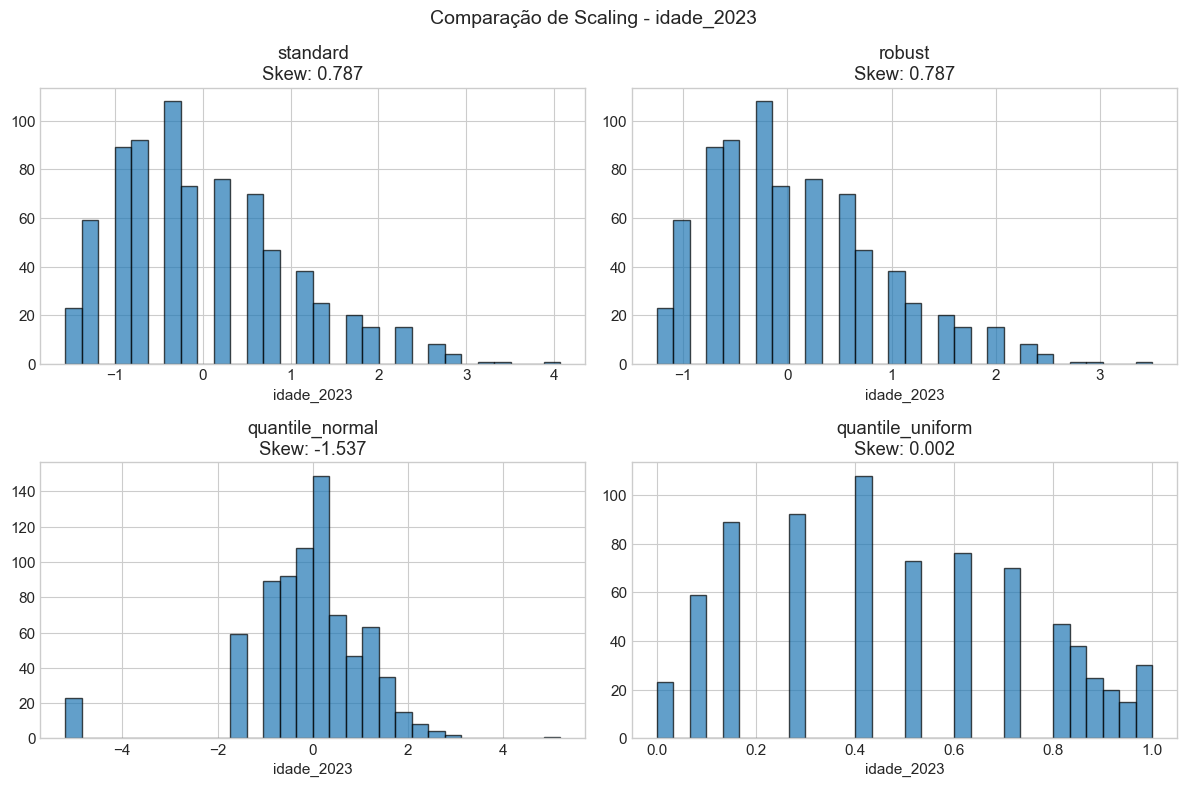

In [10]:
# Comparar diferentes estratégias de scaling
print("🔬 COMPARANDO ESTRATÉGIAS DE SCALING")
print("="*60)

scaling_strategies = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'quantile_normal': QuantileTransformer(output_distribution='normal', random_state=SEED),
    'quantile_uniform': QuantileTransformer(output_distribution='uniform', random_state=SEED)
}

# Pegar uma feature para demonstrar
demo_col = numeric_cols[0] if numeric_cols else None

if demo_col:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    X_demo = X[[demo_col]].dropna()
    
    for ax, (name, scaler) in zip(axes, scaling_strategies.items()):
        scaled = scaler.fit_transform(X_demo)
        ax.hist(scaled, bins=30, alpha=0.7, edgecolor='black')
        ax.set_title(f'{name}\nSkew: {pd.Series(scaled.flatten()).skew():.3f}')
        ax.set_xlabel(demo_col)
    
    plt.suptitle(f'Comparação de Scaling - {demo_col}', fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Feature Engineering <a id='5-features'></a>

In [12]:
def create_advanced_features(df, feature_cols, year_suffix='_2023'):
    """
    Cria features avançadas para melhorar a discriminação do modelo.
    """
    df_feat = df.copy()
    new_features = []
    
    # Identificar colunas NUMÉRICAS de indicadores
    numeric_feature_cols = df_feat[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    
    indicator_cols = [c for c in numeric_feature_cols if any(
        ind in c.lower() for ind in ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
    )]
    
    print(f"📊 Indicadores numéricos encontrados: {indicator_cols}")
    
    # 1. RAZÕES ENTRE INDICADORES (apenas numéricos)
    if len(indicator_cols) >= 2:
        for i, col1 in enumerate(indicator_cols):
            for col2 in indicator_cols[i+1:]:
                ratio_name = f'ratio_{col1.split("_")[0]}_{col2.split("_")[0]}'
                df_feat[ratio_name] = df_feat[col1] / (df_feat[col2] + 1e-6)
                new_features.append(ratio_name)
    
    # 2. ESTATÍSTICAS AGREGADAS DOS INDICADORES
    if indicator_cols:
        df_feat['indicadores_mean'] = df_feat[indicator_cols].mean(axis=1)
        df_feat['indicadores_std'] = df_feat[indicator_cols].std(axis=1)
        df_feat['indicadores_min'] = df_feat[indicator_cols].min(axis=1)
        df_feat['indicadores_max'] = df_feat[indicator_cols].max(axis=1)
        df_feat['indicadores_range'] = df_feat['indicadores_max'] - df_feat['indicadores_min']
        df_feat['indicadores_skew'] = df_feat[indicator_cols].skew(axis=1)
        new_features.extend(['indicadores_mean', 'indicadores_std', 'indicadores_min', 
                            'indicadores_max', 'indicadores_range', 'indicadores_skew'])
    
    # 3. CONTAGEM DE INDICADORES ABAIXO DA MÉDIA
    if indicator_cols:
        for col in indicator_cols:
            median_val = df_feat[col].median()
            flag_name = f'{col}_below_median'
            df_feat[flag_name] = (df_feat[col] < median_val).astype(int)
            new_features.append(flag_name)
        
        below_cols = [c for c in df_feat.columns if '_below_median' in c]
        df_feat['n_indicators_below_median'] = df_feat[below_cols].sum(axis=1)
        new_features.append('n_indicators_below_median')
    
    # 4. INTERAÇÃO FASE x IDADE (detectar defasagem atual)
    idade_col = [c for c in numeric_feature_cols if 'idade' in c.lower()]
    fase_col = [c for c in feature_cols if 'fase' in c.lower() and 'ideal' not in c.lower()]
    
    if idade_col:
        idade_col = idade_col[0]
        
        # Idade ao quadrado (relação não-linear)
        df_feat['idade_squared'] = df_feat[idade_col] ** 2
        new_features.append('idade_squared')
        
        # Tentar criar defasagem_atual se fase for numérica ou puder ser convertida
        if fase_col:
            fase_col = fase_col[0]
            
            # Converter fase para numérico se for categórica
            if df_feat[fase_col].dtype == 'object' or df_feat[fase_col].dtype.name == 'category':
                # Mapear fases conhecidas para valores numéricos
                fase_mapping = {
                    'ALFA': 0, 'alfa': 0,
                    'F1': 1, 'f1': 1,
                    'F2': 2, 'f2': 2,
                    'F3': 3, 'f3': 3,
                    'F4': 4, 'f4': 4,
                    'F5': 5, 'f5': 5,
                    'F6': 6, 'f6': 6,
                    'F7': 7, 'f7': 7,
                    'F8': 8, 'f8': 8,
                    'F9': 9, 'f9': 9,
                }
                fase_numeric = df_feat[fase_col].map(fase_mapping)
                
                # Se mapeamento funcionou para maioria
                if fase_numeric.notna().sum() > len(df_feat) * 0.5:
                    df_feat['fase_numeric'] = fase_numeric
                    df_feat['defasagem_atual'] = df_feat[idade_col] - df_feat['fase_numeric'] - 6
                    df_feat['defasagem_atual_flag'] = (df_feat['defasagem_atual'] > 0).astype(int)
                    new_features.extend(['fase_numeric', 'defasagem_atual', 'defasagem_atual_flag'])
                    print(f"   ✅ Fase convertida para numérico e defasagem calculada")
                else:
                    print(f"   ⚠️ Fase '{fase_col}' não pôde ser mapeada para numérico")
            else:
                # Fase já é numérica
                df_feat['defasagem_atual'] = df_feat[idade_col] - df_feat[fase_col] - 6
                df_feat['defasagem_atual_flag'] = (df_feat['defasagem_atual'] > 0).astype(int)
                new_features.extend(['defasagem_atual', 'defasagem_atual_flag'])
    
    # 5. FEATURES DE MISSING (informativos)
    for col in feature_cols:
        if df_feat[col].isnull().sum() > 0:
            missing_flag = f'{col}_missing'
            df_feat[missing_flag] = df_feat[col].isnull().astype(int)
            new_features.append(missing_flag)
    
    # Contar total de missings por linha
    df_feat['n_missing_features'] = df_feat[feature_cols].isnull().sum(axis=1)
    new_features.append('n_missing_features')
    
    print(f"\n✅ Features criadas: {len(new_features)}")
    print(f"📊 Novas features: {new_features[:10]}...")
    
    return df_feat, new_features

# Aplicar feature engineering
df_engineered, new_features = create_advanced_features(df, FEATURE_COLS)
print(f"\n📊 Shape após feature engineering: {df_engineered.shape}")

📊 Indicadores numéricos encontrados: ['idade_2023', 'ian_2023', 'ida_2023', 'ieg_2023', 'iaa_2023', 'ips_2023', 'ipp_2023', 'ipv_2023']
   ⚠️ Fase 'fase_2023' não pôde ser mapeada para numérico

✅ Features criadas: 51
📊 Novas features: ['ratio_idade_ian', 'ratio_idade_ida', 'ratio_idade_ieg', 'ratio_idade_iaa', 'ratio_idade_ips', 'ratio_idade_ipp', 'ratio_idade_ipv', 'ratio_ian_ida', 'ratio_ian_ieg', 'ratio_ian_iaa']...

📊 Shape após feature engineering: (765, 65)


In [13]:
# Atualizar lista de features
ALL_FEATURES = FEATURE_COLS + new_features
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_engineered.columns]

print(f"📊 Total de features: {len(ALL_FEATURES)}")

# Preparar dados para modelagem
X_full = df_engineered[ALL_FEATURES].copy()
y_full = df_engineered[TARGET_COL].copy()

# Tratar categóricas se existirem
cat_cols = X_full.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f"\n🔄 Encoding categóricas: {cat_cols}")
    for col in cat_cols:
        le = LabelEncoder()
        X_full[col] = le.fit_transform(X_full[col].astype(str))

# Imputar missing
if X_full.isnull().sum().sum() > 0:
    print("\n🔄 Imputando missing values com KNNImputer...")
    imputer = KNNImputer(n_neighbors=5)
    X_full = pd.DataFrame(
        imputer.fit_transform(X_full),
        columns=X_full.columns,
        index=X_full.index
    )

print(f"\n✅ Dados prontos para modelagem")
print(f"   X shape: {X_full.shape}")
print(f"   y shape: {y_full.shape}")

📊 Total de features: 63

🔄 Encoding categóricas: ['instituicao_2023', 'genero_2023', 'fase_2023']

🔄 Imputando missing values com KNNImputer...

✅ Dados prontos para modelagem
   X shape: (765, 63)
   y shape: (765,)


## 6. Comparação de Modelos <a id='6-modelos'></a>

In [14]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y_full
)

print(f"📊 Train: {X_train.shape} | Test: {X_test.shape}")
print(f"📊 Train target distribution: {y_train.value_counts(normalize=True).to_dict()}")
print(f"📊 Test target distribution: {y_test.value_counts(normalize=True).to_dict()}")

📊 Train: (612, 63) | Test: (153, 63)
📊 Train target distribution: {0: 0.5980392156862745, 1: 0.4019607843137255}
📊 Test target distribution: {0: 0.5947712418300654, 1: 0.40522875816993464}


In [15]:
# Definir modelos para comparação
def get_models():
    """Retorna dicionário de modelos para comparação."""
    models = {
        # Baselines
        'LogisticRegression': LogisticRegression(
            random_state=SEED, max_iter=1000, class_weight='balanced'
        ),
        'LogisticRegression_L1': LogisticRegression(
            random_state=SEED, max_iter=1000, class_weight='balanced',
            penalty='l1', solver='saga'
        ),
        
        # Tree-based
        'RandomForest': RandomForestClassifier(
            n_estimators=200, random_state=SEED, class_weight='balanced',
            max_depth=10, min_samples_leaf=5
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=200, random_state=SEED,
            max_depth=5, min_samples_leaf=10
        ),
        'HistGradientBoosting': HistGradientBoostingClassifier(
            random_state=SEED, max_iter=200, max_depth=10,
            class_weight='balanced'
        ),
    }
    
    # XGBoost
    if HAS_XGBOOST:
        # Calcular scale_pos_weight para balanceamento
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=200, random_state=SEED,
            max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            eval_metric='aucpr',
            use_label_encoder=False
        )
    
    # LightGBM
    if HAS_LIGHTGBM:
        models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=200, random_state=SEED,
            max_depth=6, learning_rate=0.1,
            class_weight='balanced',
            verbose=-1
        )
    
    # CatBoost
    if HAS_CATBOOST:
        models['CatBoost'] = CatBoostClassifier(
            iterations=200, random_state=SEED,
            depth=6, learning_rate=0.1,
            auto_class_weights='Balanced',
            verbose=False
        )
    
    return models

models = get_models()
print(f"📊 Modelos para comparação: {list(models.keys())}")

📊 Modelos para comparação: ['LogisticRegression', 'LogisticRegression_L1', 'RandomForest', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [16]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Treina e avalia um modelo, retornando métricas detalhadas.
    """
    # Treinar
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'brier': brier_score_loss(y_test, y_proba),
    }
    
    # Encontrar melhor threshold para F1
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)
    best_idx = np.argmax(f1_scores)
    
    if best_idx < len(thresholds):
        best_threshold = thresholds[best_idx]
        y_pred_best = (y_proba >= best_threshold).astype(int)
        
        metrics['best_threshold'] = best_threshold
        metrics['best_f1'] = f1_scores[best_idx]
        metrics['best_precision'] = precision_score(y_test, y_pred_best, zero_division=0)
        metrics['best_recall'] = recall_score(y_test, y_pred_best, zero_division=0)
    else:
        metrics['best_threshold'] = 0.5
        metrics['best_f1'] = metrics['f1']
        metrics['best_precision'] = metrics['precision']
        metrics['best_recall'] = metrics['recall']
    
    return metrics, model, y_proba

# Avaliar todos os modelos
print("🔬 AVALIANDO MODELOS...")
print("="*80)

results = []
trained_models = {}
probas = {}

for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")
    try:
        metrics, trained_model, y_proba = evaluate_model(
            model, X_train, y_train, X_test, y_test, name
        )
        results.append(metrics)
        trained_models[name] = trained_model
        probas[name] = y_proba
        print(f"   ✅ PR-AUC: {metrics['pr_auc']:.4f} | F1: {metrics['f1']:.4f} | Best F1: {metrics['best_f1']:.4f}")
    except Exception as e:
        print(f"   ❌ Erro: {e}")

print("\n" + "="*80)

🔬 AVALIANDO MODELOS...

🔄 Treinando LogisticRegression...
   ✅ PR-AUC: 0.8272 | F1: 0.7737 | Best F1: 0.8031

🔄 Treinando LogisticRegression_L1...
   ✅ PR-AUC: 0.6033 | F1: 0.3678 | Best F1: 0.6250

🔄 Treinando RandomForest...
   ✅ PR-AUC: 0.8817 | F1: 0.8254 | Best F1: 0.8346

🔄 Treinando GradientBoosting...
   ✅ PR-AUC: 0.8812 | F1: 0.8099 | Best F1: 0.8504

🔄 Treinando HistGradientBoosting...
   ✅ PR-AUC: 0.8690 | F1: 0.8293 | Best F1: 0.8504

🔄 Treinando XGBoost...
   ✅ PR-AUC: 0.8506 | F1: 0.8618 | Best F1: 0.8640

🔄 Treinando LightGBM...
   ✅ PR-AUC: 0.8514 | F1: 0.8099 | Best F1: 0.8308

🔄 Treinando CatBoost...
   ✅ PR-AUC: 0.8767 | F1: 0.8264 | Best F1: 0.8730



In [17]:
# Criar DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('pr_auc', ascending=False)

print("📊 COMPARAÇÃO DE MODELOS (ordenado por PR-AUC):")
print("="*100)

display_cols = ['model', 'pr_auc', 'roc_auc', 'best_f1', 'best_precision', 
                'best_recall', 'best_threshold', 'brier']
display(results_df[display_cols].round(4))

📊 COMPARAÇÃO DE MODELOS (ordenado por PR-AUC):


,model,pr_auc,roc_auc,best_f1,best_precision,best_recall,best_threshold,brier
2,RandomForest,0.8817,0.9311,0.8346,0.8154,0.8548,0.4907,0.1118
3,GradientBoosting,0.8812,0.9167,0.8504,0.8308,0.8710,0.2371,0.1180
7,CatBoost,0.8767,0.9266,0.8730,0.8594,0.8871,0.4068,0.1057
4,HistGradientBoosting,0.8690,0.9217,0.8504,0.8308,0.8710,0.3009,0.1165
6,LightGBM,0.8514,0.9119,0.8308,0.7941,0.8710,0.1624,0.1241
5,XGBoost,0.8506,0.9217,0.8640,0.8571,0.8710,0.3908,0.1041
0,LogisticRegression,0.8272,0.9039,0.8031,0.7846,0.8226,0.5881,0.1313
1,LogisticRegression_L1,0.6033,0.6826,0.6250,0.4615,0.9677,0.5000,0.2395


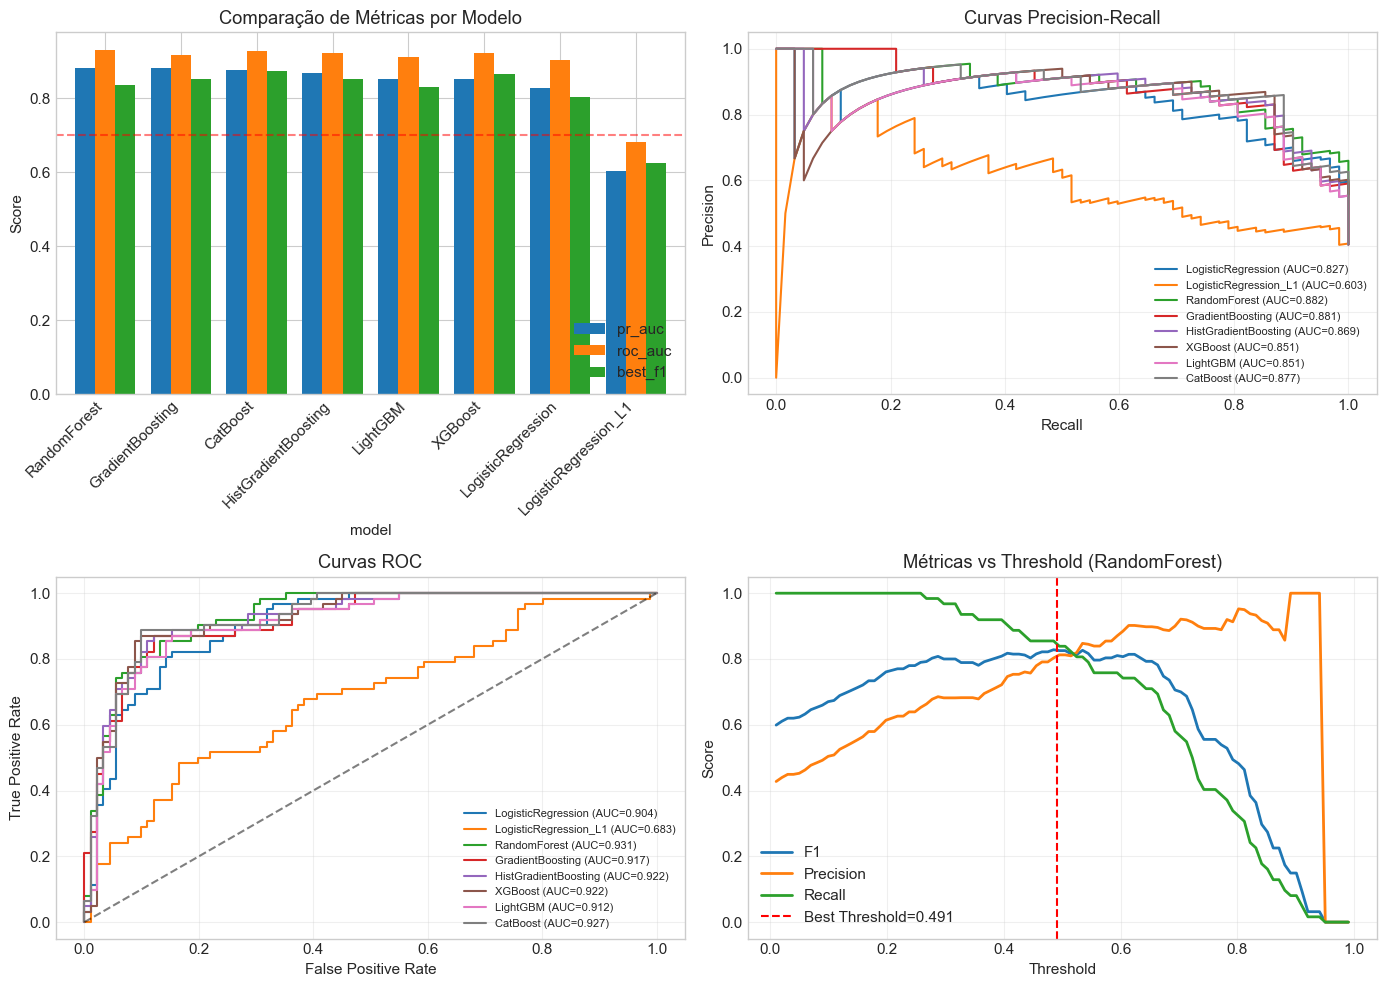


✅ Gráfico salvo em: c:\Users\argus\workspace\datathonfiap\artifacts\model_comparison_curves.png


In [18]:
# Visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barplot de métricas principais
ax1 = axes[0, 0]
metrics_to_plot = ['pr_auc', 'roc_auc', 'best_f1']
results_df[metrics_to_plot + ['model']].set_index('model').plot(
    kind='bar', ax=ax1, width=0.8
)
ax1.set_title('Comparação de Métricas por Modelo')
ax1.set_ylabel('Score')
ax1.legend(loc='lower right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Meta F1=0.7')

# 2. PR Curves
ax2 = axes[0, 1]
for name, proba in probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax2.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Curvas Precision-Recall')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. ROC Curves
ax3 = axes[1, 0]
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    ax3.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Curvas ROC')
ax3.legend(loc='lower right', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Threshold vs Metrics para o melhor modelo
ax4 = axes[1, 1]
best_model_name = results_df.iloc[0]['model']
best_proba = probas[best_model_name]

thresholds_range = np.linspace(0.01, 0.99, 100)
f1_by_thresh = []
prec_by_thresh = []
rec_by_thresh = []

for t in thresholds_range:
    y_pred_t = (best_proba >= t).astype(int)
    f1_by_thresh.append(f1_score(y_test, y_pred_t, zero_division=0))
    prec_by_thresh.append(precision_score(y_test, y_pred_t, zero_division=0))
    rec_by_thresh.append(recall_score(y_test, y_pred_t, zero_division=0))

ax4.plot(thresholds_range, f1_by_thresh, label='F1', linewidth=2)
ax4.plot(thresholds_range, prec_by_thresh, label='Precision', linewidth=2)
ax4.plot(thresholds_range, rec_by_thresh, label='Recall', linewidth=2)
ax4.axvline(x=results_df.iloc[0]['best_threshold'], color='red', linestyle='--', 
            label=f"Best Threshold={results_df.iloc[0]['best_threshold']:.3f}")
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Score')
ax4.set_title(f'Métricas vs Threshold ({best_model_name})')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico salvo em: {ARTIFACTS_PATH / 'model_comparison_curves.png'}")

## 7. Otimização com Optuna <a id='7-optuna'></a>

In [19]:
if HAS_OPTUNA:
    print("🔬 OTIMIZAÇÃO DE HIPERPARÂMETROS COM OPTUNA")
    print("="*60)
    
    # Escolher o melhor modelo base para otimizar
    best_base_model = results_df.iloc[0]['model']
    print(f"\n📊 Otimizando: {best_base_model}")
else:
    print("⚠️ Optuna não disponível. Instale com: pip install optuna")

🔬 OTIMIZAÇÃO DE HIPERPARÂMETROS COM OPTUNA

📊 Otimizando: RandomForest


In [20]:
if HAS_OPTUNA and HAS_LIGHTGBM:
    
    def objective_lgbm(trial):
        """Objective function para otimizar LightGBM."""
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': SEED,
            'class_weight': 'balanced',
            'verbose': -1,
        }
        
        # Cross-validation
        model = lgb.LGBMClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        
        scores = cross_val_score(
            model, X_train, y_train, 
            cv=cv, scoring='average_precision'
        )
        
        return scores.mean()
    
    # Criar estudo
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study_lgbm = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        study_name='lgbm_optimization'
    )
    
    print("🔄 Executando otimização LightGBM (50 trials)...")
    study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
    
    print(f"\n✅ Melhor PR-AUC (CV): {study_lgbm.best_value:.4f}")
    print(f"\n📊 Melhores parâmetros:")
    for key, value in study_lgbm.best_params.items():
        print(f"   {key}: {value}")

🔄 Executando otimização LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Melhor PR-AUC (CV): 0.8430

📊 Melhores parâmetros:
   n_estimators: 318
   max_depth: 3
   learning_rate: 0.041299735490509165
   num_leaves: 71
   min_child_samples: 47
   subsample: 0.620071494794409
   colsample_bytree: 0.7165251364221336
   reg_alpha: 1.6836747639980435e-05
   reg_lambda: 9.38820243210339e-08


In [21]:
if HAS_OPTUNA and HAS_XGBOOST:
    
    def objective_xgb(trial):
        """Objective function para otimizar XGBoost."""
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'scale_pos_weight': scale_pos_weight,
            'random_state': SEED,
            'eval_metric': 'aucpr',
            'use_label_encoder': False,
        }
        
        model = xgb.XGBClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        
        scores = cross_val_score(
            model, X_train, y_train, 
            cv=cv, scoring='average_precision'
        )
        
        return scores.mean()
    
    study_xgb = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        study_name='xgb_optimization'
    )
    
    print("🔄 Executando otimização XGBoost (50 trials)...")
    study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
    
    print(f"\n✅ Melhor PR-AUC (CV): {study_xgb.best_value:.4f}")
    print(f"\n📊 Melhores parâmetros:")
    for key, value in study_xgb.best_params.items():
        print(f"   {key}: {value}")

🔄 Executando otimização XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Melhor PR-AUC (CV): 0.8398

📊 Melhores parâmetros:
   n_estimators: 150
   max_depth: 3
   learning_rate: 0.03357298176751253
   min_child_weight: 4
   subsample: 0.7171781358782057
   colsample_bytree: 0.865042426595599
   gamma: 0.0012135764675231364
   reg_alpha: 0.0029151336209232823
   reg_lambda: 1.9082322636172772e-08


In [22]:
# Treinar modelo otimizado e comparar
if HAS_OPTUNA:
    print("\n🔬 COMPARAÇÃO: MODELO BASE vs OTIMIZADO")
    print("="*60)
    
    optimized_results = []
    
    if HAS_LIGHTGBM and 'study_lgbm' in dir():
        # Treinar LightGBM otimizado
        lgbm_opt = lgb.LGBMClassifier(
            **study_lgbm.best_params,
            random_state=SEED,
            class_weight='balanced',
            verbose=-1
        )
        metrics_lgbm, _, _ = evaluate_model(
            lgbm_opt, X_train, y_train, X_test, y_test, 'LightGBM_Optimized'
        )
        optimized_results.append(metrics_lgbm)
        print(f"\n✅ LightGBM Otimizado:")
        print(f"   PR-AUC: {metrics_lgbm['pr_auc']:.4f}")
        print(f"   Best F1: {metrics_lgbm['best_f1']:.4f}")
    
    if HAS_XGBOOST and 'study_xgb' in dir():
        # Treinar XGBoost otimizado
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        xgb_opt = xgb.XGBClassifier(
            **study_xgb.best_params,
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            eval_metric='aucpr',
            use_label_encoder=False
        )
        metrics_xgb, _, _ = evaluate_model(
            xgb_opt, X_train, y_train, X_test, y_test, 'XGBoost_Optimized'
        )
        optimized_results.append(metrics_xgb)
        print(f"\n✅ XGBoost Otimizado:")
        print(f"   PR-AUC: {metrics_xgb['pr_auc']:.4f}")
        print(f"   Best F1: {metrics_xgb['best_f1']:.4f}")
    
    # Adicionar aos resultados
    if optimized_results:
        results_df_opt = pd.concat([
            results_df,
            pd.DataFrame(optimized_results)
        ]).sort_values('pr_auc', ascending=False)
        
        print("\n📊 RANKING ATUALIZADO:")
        display(results_df_opt[display_cols].round(4))


🔬 COMPARAÇÃO: MODELO BASE vs OTIMIZADO

✅ LightGBM Otimizado:
   PR-AUC: 0.8553
   Best F1: 0.8455

✅ XGBoost Otimizado:
   PR-AUC: 0.8676
   Best F1: 0.8387

📊 RANKING ATUALIZADO:


,model,pr_auc,roc_auc,best_f1,best_precision,best_recall,best_threshold,brier
2,RandomForest,0.8817,0.9311,0.8346,0.8154,0.8548,0.4907,0.1118
3,GradientBoosting,0.8812,0.9167,0.8504,0.8308,0.8710,0.2371,0.1180
7,CatBoost,0.8767,0.9266,0.8730,0.8594,0.8871,0.4068,0.1057
4,HistGradientBoosting,0.8690,0.9217,0.8504,0.8308,0.8710,0.3009,0.1165
1,XGBoost_Optimized,0.8676,0.9188,0.8387,0.8387,0.8387,0.5056,0.1114
0,LightGBM_Optimized,0.8553,0.9176,0.8455,0.8525,0.8387,0.4903,0.1099
6,LightGBM,0.8514,0.9119,0.8308,0.7941,0.8710,0.1624,0.1241
5,XGBoost,0.8506,0.9217,0.8640,0.8571,0.8710,0.3908,0.1041
0,LogisticRegression,0.8272,0.9039,0.8031,0.7846,0.8226,0.5881,0.1313
1,LogisticRegression_L1,0.6033,0.6826,0.6250,0.4615,0.9677,0.5000,0.2395


## 8. Técnicas de Balanceamento <a id='8-balanceamento'></a>

In [23]:
if HAS_IMBLEARN:
    print("🔬 COMPARAÇÃO DE TÉCNICAS DE BALANCEAMENTO")
    print("="*60)
    
    # Definir técnicas de balanceamento
    sampling_strategies = {
        'No_Sampling': None,
        'SMOTE': SMOTE(random_state=SEED),
        'BorderlineSMOTE': BorderlineSMOTE(random_state=SEED),
        'ADASYN': ADASYN(random_state=SEED),
        'SMOTETomek': SMOTETomek(random_state=SEED),
    }
    
    # Modelo base para teste (LightGBM ou RF)
    if HAS_LIGHTGBM:
        base_model = lgb.LGBMClassifier(
            n_estimators=200, random_state=SEED, verbose=-1
        )
        model_name = "LightGBM"
    else:
        base_model = RandomForestClassifier(
            n_estimators=200, random_state=SEED
        )
        model_name = "RandomForest"
    
    sampling_results = []
    
    for name, sampler in sampling_strategies.items():
        print(f"\n🔄 Testando {name}...")
        try:
            if sampler is None:
                X_resampled, y_resampled = X_train, y_train
            else:
                X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
            
            print(f"   Shape após sampling: {X_resampled.shape}")
            print(f"   Distribuição: {pd.Series(y_resampled).value_counts().to_dict()}")
            
            # Treinar e avaliar
            model = base_model.__class__(**base_model.get_params())
            metrics, _, _ = evaluate_model(
                model, X_resampled, y_resampled, X_test, y_test, f"{model_name}_{name}"
            )
            metrics['sampling'] = name
            sampling_results.append(metrics)
            
            print(f"   ✅ PR-AUC: {metrics['pr_auc']:.4f} | Best F1: {metrics['best_f1']:.4f}")
            
        except Exception as e:
            print(f"   ❌ Erro: {e}")
    
    # Resultados
    sampling_df = pd.DataFrame(sampling_results)
    sampling_df = sampling_df.sort_values('pr_auc', ascending=False)
    
    print("\n📊 COMPARAÇÃO DE TÉCNICAS DE BALANCEAMENTO:")
    display(sampling_df[['sampling', 'pr_auc', 'roc_auc', 'best_f1', 
                         'best_precision', 'best_recall']].round(4))
else:
    print("⚠️ Imbalanced-learn não disponível. Instale com: pip install imbalanced-learn")

🔬 COMPARAÇÃO DE TÉCNICAS DE BALANCEAMENTO

🔄 Testando No_Sampling...
   Shape após sampling: (612, 63)
   Distribuição: {0: 366, 1: 246}
   ✅ PR-AUC: 0.8534 | Best F1: 0.8413

🔄 Testando SMOTE...
   Shape após sampling: (732, 63)
   Distribuição: {0: 366, 1: 366}
   ✅ PR-AUC: 0.8679 | Best F1: 0.8480

🔄 Testando BorderlineSMOTE...
   Shape após sampling: (732, 63)
   Distribuição: {0: 366, 1: 366}
   ✅ PR-AUC: 0.8462 | Best F1: 0.8413

🔄 Testando ADASYN...
   Shape após sampling: (724, 63)
   Distribuição: {0: 366, 1: 358}
   ✅ PR-AUC: 0.8547 | Best F1: 0.8276

🔄 Testando SMOTETomek...
   Shape após sampling: (682, 63)
   Distribuição: {0: 341, 1: 341}
   ✅ PR-AUC: 0.8752 | Best F1: 0.8500

📊 COMPARAÇÃO DE TÉCNICAS DE BALANCEAMENTO:


,sampling,pr_auc,roc_auc,best_f1,best_precision,best_recall
4,SMOTETomek,0.8752,0.9210,0.8500,0.8793,0.8226
1,SMOTE,0.8679,0.9178,0.8480,0.8413,0.8548
3,ADASYN,0.8547,0.9133,0.8276,0.8889,0.7742
0,No_Sampling,0.8534,0.9121,0.8413,0.8281,0.8548
2,BorderlineSMOTE,0.8462,0.9075,0.8413,0.8281,0.8548


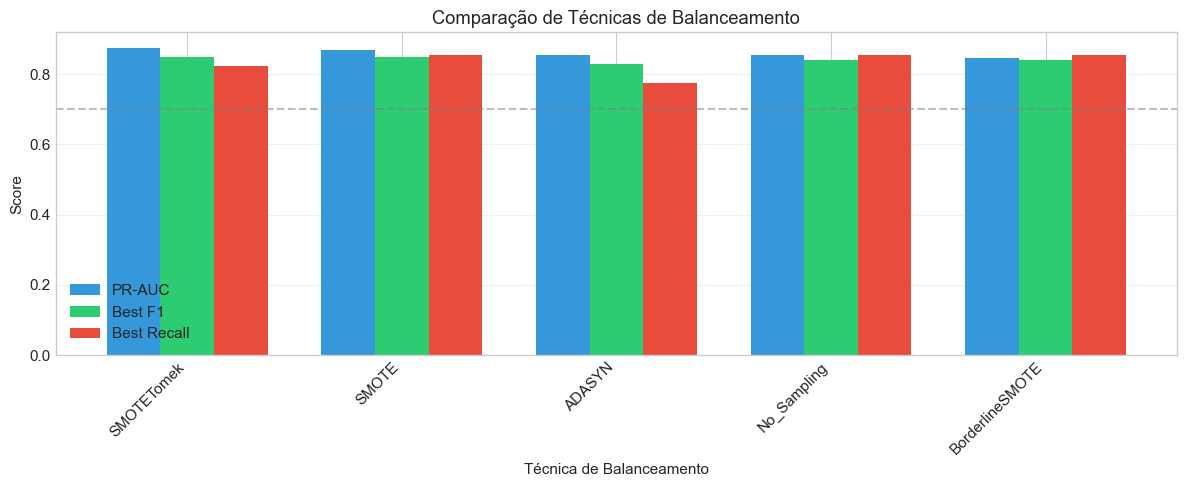

In [24]:
# Visualização das técnicas de balanceamento
if HAS_IMBLEARN and len(sampling_results) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    x = np.arange(len(sampling_df))
    width = 0.25
    
    ax.bar(x - width, sampling_df['pr_auc'], width, label='PR-AUC', color='#3498db')
    ax.bar(x, sampling_df['best_f1'], width, label='Best F1', color='#2ecc71')
    ax.bar(x + width, sampling_df['best_recall'], width, label='Best Recall', color='#e74c3c')
    
    ax.set_xlabel('Técnica de Balanceamento')
    ax.set_ylabel('Score')
    ax.set_title('Comparação de Técnicas de Balanceamento')
    ax.set_xticks(x)
    ax.set_xticklabels(sampling_df['sampling'], rotation=45, ha='right')
    ax.legend()
    ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(ARTIFACTS_PATH / 'sampling_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Análise Final e Recomendações <a id='9-conclusao'></a>

In [25]:
# Consolidar todos os resultados
print("📊 RESUMO FINAL DOS EXPERIMENTOS")
print("="*80)

all_results = results.copy()

if HAS_OPTUNA and 'optimized_results' in dir() and optimized_results:
    all_results.extend(optimized_results)

final_df = pd.DataFrame(all_results)
final_df = final_df.sort_values('pr_auc', ascending=False)

print("\n🏆 TOP 5 MODELOS (por PR-AUC):")
display(final_df[display_cols].head().round(4))

# Melhor modelo
best = final_df.iloc[0]
print(f"\n🥇 MELHOR MODELO: {best['model']}")
print(f"   PR-AUC: {best['pr_auc']:.4f}")
print(f"   ROC-AUC: {best['roc_auc']:.4f}")
print(f"   Best F1: {best['best_f1']:.4f}")
print(f"   Best Precision: {best['best_precision']:.4f}")
print(f"   Best Recall: {best['best_recall']:.4f}")
print(f"   Threshold: {best['best_threshold']:.4f}")

📊 RESUMO FINAL DOS EXPERIMENTOS

🏆 TOP 5 MODELOS (por PR-AUC):


,model,pr_auc,roc_auc,best_f1,best_precision,best_recall,best_threshold,brier
2,RandomForest,0.8817,0.9311,0.8346,0.8154,0.8548,0.4907,0.1118
3,GradientBoosting,0.8812,0.9167,0.8504,0.8308,0.8710,0.2371,0.1180
7,CatBoost,0.8767,0.9266,0.8730,0.8594,0.8871,0.4068,0.1057
4,HistGradientBoosting,0.8690,0.9217,0.8504,0.8308,0.8710,0.3009,0.1165
9,XGBoost_Optimized,0.8676,0.9188,0.8387,0.8387,0.8387,0.5056,0.1114



🥇 MELHOR MODELO: RandomForest
   PR-AUC: 0.8817
   ROC-AUC: 0.9311
   Best F1: 0.8346
   Best Precision: 0.8154
   Best Recall: 0.8548
   Threshold: 0.4907


In [26]:
# Comparação com modelo atual
print("\n📊 COMPARAÇÃO: MODELO ATUAL vs MELHOR NOVO MODELO")
print("="*80)

if current_metrics:
    # Pegar métricas do modelo atual
    current = None
    for name, metrics in current_metrics.items():
        if 'validation_metrics' in metrics:
            current = metrics['validation_metrics']
            break
        elif 'baselines' in metrics:
            # Pegar o melhor baseline
            best_baseline = metrics.get('best_model', '')
            if best_baseline in metrics['baselines']:
                current = metrics['baselines'][best_baseline]
                break
    
    if current:
        comparison = pd.DataFrame({
            'Métrica': ['PR-AUC', 'F1', 'Precision', 'Recall', 'Threshold'],
            'Modelo Atual': [
                current.get('pr_auc', 'N/A'),
                current.get('f1', 'N/A'),
                current.get('precision', 'N/A'),
                current.get('recall', 'N/A'),
                current_metrics.get('metrics_v1.json', {}).get('threshold', 
                    current_metrics.get('metrics.json', {}).get('threshold', 'N/A'))
            ],
            'Novo Melhor': [
                best['pr_auc'],
                best['best_f1'],
                best['best_precision'],
                best['best_recall'],
                best['best_threshold']
            ]
        })
        
        # Calcular diferença
        comparison['Diferença'] = comparison.apply(
            lambda row: f"+{row['Novo Melhor'] - row['Modelo Atual']:.4f}" 
            if isinstance(row['Modelo Atual'], (int, float)) else 'N/A',
            axis=1
        )
        
        display(comparison)
else:
    print("⚠️ Métricas do modelo atual não disponíveis para comparação")


📊 COMPARAÇÃO: MODELO ATUAL vs MELHOR NOVO MODELO


,Métrica,Modelo Atual,Novo Melhor,Diferença
0,PR-AUC,0.891635,0.881725,+-0.0099
1,F1,0.576744,0.834646,+0.2579
2,Precision,0.405229,0.815385,+0.4102
3,Recall,1.000000,0.854839,+-0.1452
4,Threshold,0.026820,0.490695,+0.4639


In [ ]:
# Recomendações finais
print("\n" + "="*80)
print("📋 RECOMENDAÇÕES FINAIS")
print("="*80)

recommendations = """
🎯 AÇÕES RECOMENDADAS:

1. MODELO:
   - Adotar o modelo com melhor PR-AUC nos experimentos
   - Se LightGBM/XGBoost otimizado > base, usar versão otimizada
   - Considerar ensemble (Stacking) se ganho justificar complexidade

2. PRÉ-PROCESSAMENTO:
   - Usar KNNImputer ao invés de SimpleImputer(median)
   - Considerar RobustScaler para features com outliers
   - Manter indicadores de missing como features

3. FEATURE ENGINEERING:
   - Incluir features de razão entre indicadores
   - Adicionar agregações (mean, std, min, max dos indicadores)
   - Usar defasagem_atual como feature
   - Criar flags para indicadores abaixo da mediana

4. BALANCEAMENTO:
   - Se SMOTE/BorderlineSMOTE melhorou, usar no pipeline
   - Caso contrário, confiar em class_weight='balanced'
   - CUIDADO com dataset pequeno - monitorar overfitting

5. THRESHOLD:
   - Usar threshold otimizado para F1 (não 0.5)
   - Documentar trade-off precision vs recall
   - Permitir ajuste operacional baseado em capacidade de intervenção

6. VALIDAÇÃO:
   - Sempre usar Stratified K-Fold (5-10 folds)
   - Monitorar diferença train vs validation (overfitting)
   - Reportar intervalos de confiança quando possível
"""

print(recommendations)

In [ ]:
# Salvar resultados
output = {
    'experiment_date': datetime.now().isoformat(),
    'dataset_shape': list(X_full.shape),
    'n_features_original': len(FEATURE_COLS),
    'n_features_engineered': len(ALL_FEATURES),
    'best_model': best['model'],
    'best_metrics': {
        'pr_auc': float(best['pr_auc']),
        'roc_auc': float(best['roc_auc']),
        'best_f1': float(best['best_f1']),
        'best_precision': float(best['best_precision']),
        'best_recall': float(best['best_recall']),
        'best_threshold': float(best['best_threshold']),
        'brier': float(best['brier']),
    },
    'all_results': final_df.to_dict('records'),
}

# Adicionar resultados de otimização se disponíveis
if HAS_OPTUNA:
    if 'study_lgbm' in dir():
        output['optuna_lgbm'] = {
            'best_value': study_lgbm.best_value,
            'best_params': study_lgbm.best_params,
            'n_trials': len(study_lgbm.trials)
        }
    if 'study_xgb' in dir():
        output['optuna_xgb'] = {
            'best_value': study_xgb.best_value,
            'best_params': study_xgb.best_params,
            'n_trials': len(study_xgb.trials)
        }

# Salvar
output_path = ARTIFACTS_PATH / 'model_comparison_results.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f"\n✅ Resultados salvos em: {output_path}")

In [ ]:
print("\n" + "="*80)
print("🎉 NOTEBOOK CONCLUÍDO!")
print("="*80)
print(f"""
📊 Resumo:
   - Modelos testados: {len(results)}
   - Features originais: {len(FEATURE_COLS)}
   - Features após engenharia: {len(ALL_FEATURES)}
   - Melhor modelo: {best['model']}
   - Melhor PR-AUC: {best['pr_auc']:.4f}

📁 Arquivos gerados:
   - {ARTIFACTS_PATH / 'model_comparison_results.json'}
   - {ARTIFACTS_PATH / 'model_comparison_curves.png'}
""")